## Load data and RS embeddings

In [2]:
import pandas as pd
import numpy as np
import json
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

INTERACTIONS = "../Data/interactions.parquet"
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB = "../Data/item_embeddings_rs.npy"
STEAM_GAMES = "../Data/steam_games.json"

# Load interactions and mappings
df_inter = pd.read_parquet(INTERACTIONS)
item_emb_rs = np.load(ITEM_EMB)

with open(USERMAP,"r") as f: user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: item2idx = {k:int(v) for k,v in json.load(f).items()}

# Target: total reviews per game
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"✅ RS embeddings shape: {item_emb_rs.shape}")
print(f"✅ Total items with interactions: {len(target_df)}")

✅ RS embeddings shape: (3682, 64)
✅ Total items with interactions: 3682


## Load game metadata and extract content features

In [3]:
# Load game metadata
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_games = pd.json_normalize(games)
df_games = df_games.rename(columns={"id":"item_id"})
df_games["item_idx"] = df_games["item_id"].map(item2idx)
df_games = df_games.dropna(subset=["item_idx"])
df_games["item_idx"] = df_games["item_idx"].astype(int)

print(f"Total games with metadata: {len(df_games)}")
print(f"\nAvailable fields: {df_games.columns.tolist()}")

Total games with metadata: 3195

Available fields: ['publisher', 'genres', 'app_name', 'title', 'url', 'release_date', 'tags', 'discount_price', 'reviews_url', 'specs', 'price', 'early_access', 'item_id', 'developer', 'sentiment', 'metascore', 'item_idx']


## Feature Engineering: Extract content features

In [4]:
# 1. Process tags
def parse_tags(tags):
    if tags is None or (isinstance(tags, float) and pd.isna(tags)):
        return []
    if isinstance(tags, list):
        return [str(tag).strip() for tag in tags if tag]
    if isinstance(tags, str):
        if tags == '':
            return []
        try:
            tags_list = eval(tags)
            if isinstance(tags_list, list):
                return [str(tag).strip() for tag in tags_list if tag]
        except:
            return []
    return []

df_games['tags_list'] = df_games['tags'].apply(parse_tags)
df_games['tag_text'] = df_games['tags_list'].apply(lambda x: ' '.join(x) if x else '')

# 2. Process genres
def parse_genres(genres):
    if genres is None or (isinstance(genres, float) and pd.isna(genres)):
        return []
    if isinstance(genres, list):
        return [str(g).strip() for g in genres if g]
    if isinstance(genres, str):
        if genres == '':
            return []
        try:
            genres_list = eval(genres)
            if isinstance(genres_list, list):
                return [str(g).strip() for g in genres_list if g]
        except:
            return []
    return []

df_games['genres_list'] = df_games['genres'].apply(parse_genres)
df_games['genre_text'] = df_games['genres_list'].apply(lambda x: ' '.join(x) if x else '')

# 3. Combine tags + genres into content description
df_games['content_text'] = df_games['tag_text'] + ' ' + df_games['genre_text']

# 4. Process price
def parse_price(price):
    if pd.isna(price) or price == '':
        return 0.0
    try:
        return float(price)
    except:
        return 0.0

df_games['price_num'] = df_games['price'].apply(parse_price)

# 5. Early access flag
df_games['early_access_flag'] = df_games['early_access'].apply(lambda x: 1 if x else 0)

# 6. Parse release date for temporal split
df_games['release_date_parsed'] = pd.to_datetime(df_games['release_date'], errors='coerce')

print(f"\n✅ Content features extracted")
print(f"Games with tags: {(df_games['tag_text'] != '').sum()}")
print(f"Games with genres: {(df_games['genre_text'] != '').sum()}")
print(f"Average price: ${df_games['price_num'].mean():.2f}")
print(f"\n📅 Release date range:")
print(f"  Min: {df_games['release_date_parsed'].min()}")
print(f"  Max: {df_games['release_date_parsed'].max()}")
print(f"  Games with valid dates: {df_games['release_date_parsed'].notna().sum()}")


✅ Content features extracted
Games with tags: 3193
Games with genres: 3096
Average price: $11.53

📅 Release date range:
  Min: 1989-01-01 00:00:00
  Max: 2017-12-25 00:00:00
  Games with valid dates: 3107


## Create TF-IDF features from content

In [5]:
# TF-IDF on combined content (tags + genres)
# This will penalize common tags/genres and highlight distinctive ones

tfidf = TfidfVectorizer(
    max_features=100,  # Keep top 100 most informative terms
    min_df=2,          # Ignore terms that appear in < 2 games
    max_df=0.5,        # Ignore terms that appear in > 50% of games
    ngram_range=(1, 1) # Only unigrams
)

# Fit on all games with content
games_with_content = df_games[df_games['content_text'] != ''].copy()
tfidf_matrix = tfidf.fit_transform(games_with_content['content_text'])

print(f"\n✅ TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Top 20 features: {tfidf.get_feature_names_out()[:20]}")


✅ TF-IDF matrix shape: (3195, 100)
Top 20 features: ['2d' 'access' 'and' 'anime' 'apocalyptic' 'arcade' 'atmospheric' 'based'
 'building' 'casual' 'classic' 'click' 'co' 'comedy' 'controller'
 'crafting' 'cute' 'dark' 'difficult' 'down']


## Combine RS embeddings + Content features

In [6]:
# Create mapping from item_idx to row in tfidf_matrix
item_to_tfidf = {item_idx: i for i, item_idx in enumerate(games_with_content['item_idx'])}

# For each item, combine:
# - RS embedding (64-dim)
# - TF-IDF features (100-dim)
# - Numerical features: price, early_access (2-dim)

hybrid_features = []
valid_items = []

for item_idx in range(len(item_emb_rs)):
    if item_idx not in item_to_tfidf:
        continue
    
    # RS embedding
    rs_emb = item_emb_rs[item_idx]
    
    # TF-IDF features
    tfidf_idx = item_to_tfidf[item_idx]
    tfidf_features = tfidf_matrix[tfidf_idx].toarray().flatten()
    
    # Numerical features
    game_row = games_with_content[games_with_content['item_idx'] == item_idx].iloc[0]
    price = game_row['price_num']
    early_access = game_row['early_access_flag']
    
    # Concatenate all features
    combined = np.concatenate([
        rs_emb,
        tfidf_features,
        [price, early_access]
    ])
    
    hybrid_features.append(combined)
    valid_items.append(item_idx)

X_hybrid = np.array(hybrid_features)

print(f"\n✅ Hybrid features created")
print(f"Shape: {X_hybrid.shape}")
print(f"Breakdown: 64 (RS) + 100 (TF-IDF) + 2 (numerical) = {X_hybrid.shape[1]} dims")
print(f"Valid items: {len(valid_items)}")


✅ Hybrid features created
Shape: (3195, 166)
Breakdown: 64 (RS) + 100 (TF-IDF) + 2 (numerical) = 166 dims
Valid items: 3195


## Prepare target variable

In [7]:
# Get targets for valid items
target_subset = target_df[target_df['item_idx'].isin(valid_items)].copy()
target_subset = target_subset.set_index('item_idx')

y_hybrid = target_subset.loc[valid_items]['total_reviews'].values

print(f"\n✅ Target prepared")
print(f"Shape: {y_hybrid.shape}")
print(f"Range: {y_hybrid.min()} - {y_hybrid.max()}")
print(f"Mean: {y_hybrid.mean():.1f}")


✅ Target prepared
Shape: (3195,)
Range: 1 - 3759
Mean: 16.9


## Train Hybrid Model - TEMPORAL SPLIT

**Estrategia de validación temporal:**
- Train: Juegos lanzados ANTES de un cutoff date (ej: antes de 2017-07-01)
- Test: Juegos lanzados DESPUÉS del cutoff (últimos 6-12 meses del dataset)

Esto simula predicción en producción: entrenar con juegos pasados, predecir éxito de juegos nuevos.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Get release dates for valid items
valid_items_df = pd.DataFrame({'item_idx': valid_items})
valid_items_df = valid_items_df.merge(
    df_games[['item_idx', 'release_date_parsed', 'app_name']],
    on='item_idx',
    how='left'
)

print("📅 Release date distribution for valid items:")
print(valid_items_df['release_date_parsed'].describe())

# Define temporal cutoff - use games from last 12 months as test
# Cambiado de 2017-07-01 (26 juegos) a 2017-01-01 (50 juegos) para test set más robusto
cutoff_date = pd.to_datetime('2017-01-01')  # Todo 2017 como test set

# Create temporal train/test split
train_mask = valid_items_df['release_date_parsed'] < cutoff_date
test_mask = valid_items_df['release_date_parsed'] >= cutoff_date

# Remove items without valid dates
valid_dates_mask = valid_items_df['release_date_parsed'].notna()
train_mask = train_mask & valid_dates_mask
test_mask = test_mask & valid_dates_mask

X_train_temporal = X_hybrid[train_mask]
X_test_temporal = X_hybrid[test_mask]
y_train_temporal = y_hybrid[train_mask]
y_test_temporal = y_hybrid[test_mask]

print(f"\n{'='*70}")
print("TEMPORAL SPLIT SUMMARY")
print(f"{'='*70}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train set: {len(X_train_temporal)} games (released before {cutoff_date.date()})")
print(f"Test set: {len(X_test_temporal)} games (released after {cutoff_date.date()})")
print(f"Train target range: {y_train_temporal.min():.0f} - {y_train_temporal.max():.0f} (mean: {y_train_temporal.mean():.1f})")
print(f"Test target range: {y_test_temporal.min():.0f} - {y_test_temporal.max():.0f} (mean: {y_test_temporal.mean():.1f})")
print(f"{'='*70}\n")

# Train model on temporal split
model_temporal = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

print("Training model on games released before cutoff...")
model_temporal.fit(X_train_temporal, y_train_temporal)

pred_temporal = model_temporal.predict(X_test_temporal)

mse_temporal = mean_squared_error(y_test_temporal, pred_temporal)
rmse_temporal = np.sqrt(mse_temporal)
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print("\n" + "="*70)
print("HYBRID MODEL RESULTS - TEMPORAL VALIDATION")
print("="*70)
print(f"RMSE: {rmse_temporal:.2f}")
print(f"R²: {r2_temporal:.6f}")
print("="*70)

📅 Release date distribution for valid items:
count                             3107
mean     2013-02-20 16:19:18.673962240
min                1989-01-01 00:00:00
25%                2012-04-19 00:00:00
50%                2014-05-23 00:00:00
75%                2015-08-04 12:00:00
max                2017-12-25 00:00:00
Name: release_date_parsed, dtype: object

TEMPORAL SPLIT SUMMARY
Cutoff date: 2017-01-01
Train set: 3057 games (released before 2017-01-01)
Test set: 50 games (released after 2017-01-01)
Train target range: 1 - 3759 (mean: 15.8)
Test target range: 1 - 1050 (mean: 42.1)

Training model on games released before cutoff...

HYBRID MODEL RESULTS - TEMPORAL VALIDATION
RMSE: 123.73
R²: 0.382318


## Train Hybrid Model - RANDOM SPLIT (for comparison)

In [15]:
from sklearn.model_selection import train_test_split

# Random split for comparison
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42
)

model_random = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

print("Training model with random split...")
model_random.fit(X_train_random, y_train_random)

pred_random = model_random.predict(X_test_random)

mse_random = mean_squared_error(y_test_random, pred_random)
rmse_random = np.sqrt(mse_random)
r2_random = r2_score(y_test_random, pred_random)

print("\n" + "="*70)
print("HYBRID MODEL RESULTS - RANDOM SPLIT")
print("="*70)
print(f"RMSE: {rmse_random:.2f}")
print(f"R²: {r2_random:.6f}")
print("="*70)

# Compare both strategies
print("\n" + "="*70)
print("TEMPORAL vs RANDOM SPLIT COMPARISON")
print("="*70)
comparison = pd.DataFrame({
    'Strategy': ['Temporal (Time-based)', 'Random (Shuffled)'],
    'RMSE': [rmse_temporal, rmse_random],
    'R²': [r2_temporal, r2_random],
    'Train Size': [len(X_train_temporal), len(X_train_random)],
    'Test Size': [len(X_test_temporal), len(X_test_random)]
})
print(comparison.to_string(index=False))
print("="*70)
print("\n💡 Note: Temporal split is more realistic for production deployment.")
print("   Random split may be overly optimistic due to data leakage from future.")


Training model with random split...

HYBRID MODEL RESULTS - RANDOM SPLIT
RMSE: 85.56
R²: 0.127387

TEMPORAL vs RANDOM SPLIT COMPARISON
             Strategy       RMSE       R²  Train Size  Test Size
Temporal (Time-based) 123.725329 0.382318        3057         50
    Random (Shuffled)  85.562101 0.127387        2556        639

💡 Note: Temporal split is more realistic for production deployment.
   Random split may be overly optimistic due to data leakage from future.


## Comparison with baseline models


COMPARACIÓN COMPLETA - TODOS LOS MODELOS
                         Model                           Type  Dimensions       RMSE        R²    Split
            RS Embeddings Only                  Collaborative          64  65.900000  0.608000   Random
Hybrid (RS+Content) - Temporal Hybrid (Collaborative+Content)         166 123.725329  0.382318 Temporal
  Hybrid (RS+Content) - Random Hybrid (Collaborative+Content)         166  85.562101  0.127387   Random
                Tag Embeddings           Content-based (Tags)         384 169.380000 -2.419000   Random
        Review Text Embeddings            Content-based (NLP)         384 156.530000 -1.210000   Random
             Metadata Enhanced                       Metadata          12 124.140000 -0.390000   Random


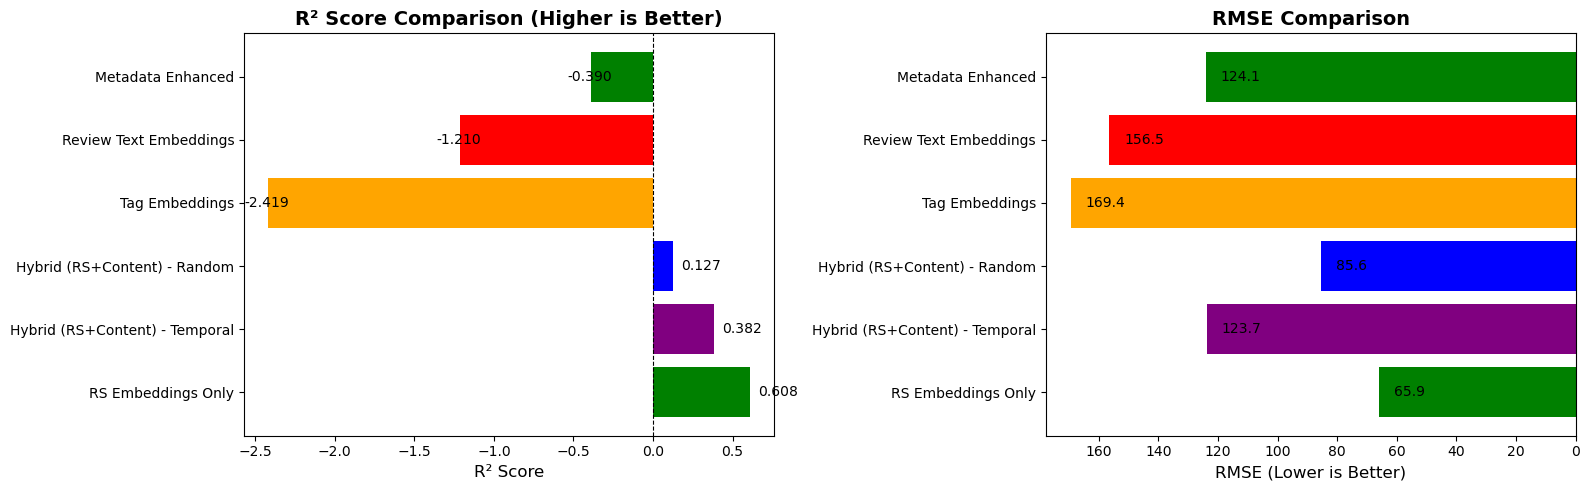

In [16]:
import matplotlib.pyplot as plt

# Compare all models (using temporal validation results)
results = pd.DataFrame({
    'Model': [
        'RS Embeddings Only',
        'Hybrid (RS+Content) - Temporal',
        'Hybrid (RS+Content) - Random',
        'Tag Embeddings',
        'Review Text Embeddings',
        'Metadata Enhanced'
    ],
    'Type': [
        'Collaborative',
        'Hybrid (Collaborative+Content)',
        'Hybrid (Collaborative+Content)',
        'Content-based (Tags)',
        'Content-based (NLP)',
        'Metadata'
    ],
    'Dimensions': [64, X_hybrid.shape[1], X_hybrid.shape[1], 384, 384, 12],
    'RMSE': [65.90, rmse_temporal, rmse_random, 169.38, 156.53, 124.14],
    'R²': [0.608, r2_temporal, r2_random, -2.419, -1.21, -0.39],
    'Split': ['Random', 'Temporal', 'Random', 'Random', 'Random', 'Random']
})

print("\n" + "="*100)
print("COMPARACIÓN COMPLETA - TODOS LOS MODELOS")
print("="*100)
print(results.to_string(index=False))
print("="*100)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# R² comparison
colors = ['green', 'purple', 'blue', 'orange', 'red']
bars1 = ax1.barh(results['Model'], results['R²'], color=colors)
ax1.set_xlabel('R² Score', fontsize=12)
ax1.set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
for i, v in enumerate(results['R²']):
    ax1.text(v + 0.05 if v > 0 else v - 0.15, i, f'{v:.3f}', va='center', fontsize=10)

# RMSE comparison
bars2 = ax2.barh(results['Model'], results['RMSE'], color=colors)
ax2.set_xlabel('RMSE (Lower is Better)', fontsize=12)
ax2.set_title('RMSE Comparison', fontsize=14, fontweight='bold')
ax2.invert_xaxis()
for i, v in enumerate(results['RMSE']):
    ax2.text(v - 5, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Feature Importance Analysis


FEATURE IMPORTANCE BY GROUP
       Feature Group  Total Importance  Avg per Feature
  RS Embeddings (64)          0.334687         0.005229
TF-IDF Content (100)          0.665306         0.006653
       Numerical (2)          0.000007         0.000004


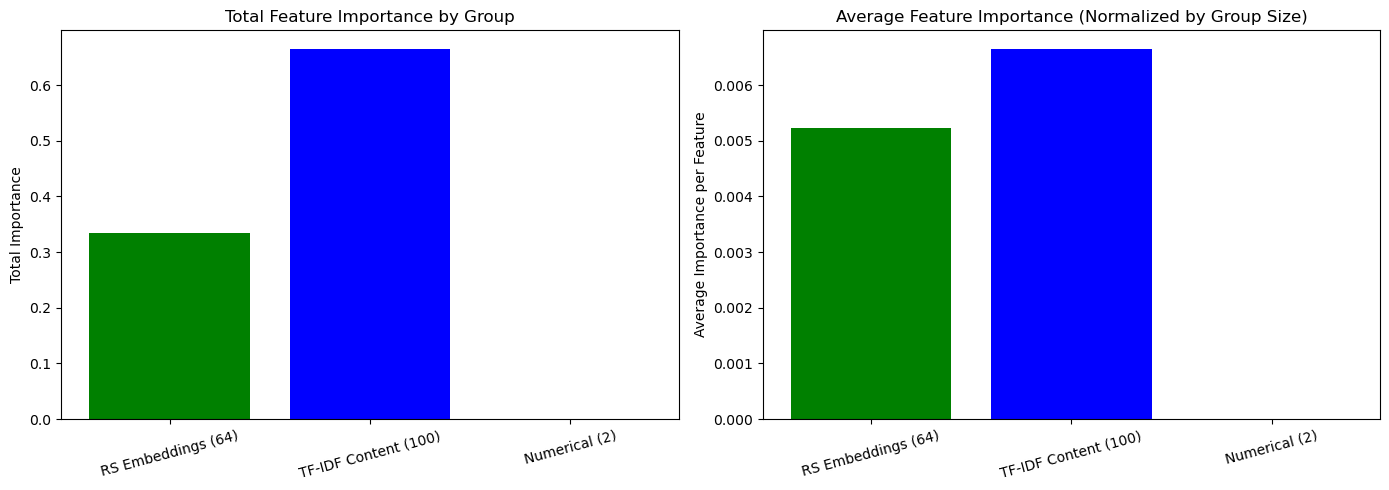

In [11]:
# Get feature importances from temporal model
importances = model_temporal.feature_importances_

# Split by feature type
rs_importance = importances[:64].sum()
tfidf_importance = importances[64:164].sum()
numerical_importance = importances[164:].sum()

feature_groups = pd.DataFrame({
    'Feature Group': ['RS Embeddings (64)', 'TF-IDF Content (100)', 'Numerical (2)'],
    'Total Importance': [rs_importance, tfidf_importance, numerical_importance],
    'Avg per Feature': [
        rs_importance / 64,
        tfidf_importance / 100,
        numerical_importance / 2
    ]
})

print("\n" + "="*70)
print("FEATURE IMPORTANCE BY GROUP")
print("="*70)
print(feature_groups.to_string(index=False))
print("="*70)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(feature_groups['Feature Group'], feature_groups['Total Importance'], color=['green', 'blue', 'orange'])
ax1.set_ylabel('Total Importance')
ax1.set_title('Total Feature Importance by Group')
ax1.tick_params(axis='x', rotation=15)

ax2.bar(feature_groups['Feature Group'], feature_groups['Avg per Feature'], color=['green', 'blue', 'orange'])
ax2.set_ylabel('Average Importance per Feature')
ax2.set_title('Average Feature Importance (Normalized by Group Size)')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Top TF-IDF features by importance

In [11]:
# Get top TF-IDF features
tfidf_features = tfidf.get_feature_names_out()
tfidf_importances = importances[64:164]

top_tfidf = pd.DataFrame({
    'Feature': tfidf_features,
    'Importance': tfidf_importances
}).sort_values('Importance', ascending=False).head(20)

print("\nTop 20 Content Features by Importance:")
print(top_tfidf.to_string(index=False))


Top 20 Content Features by Importance:
    Feature  Importance
      based    0.163485
    shooter    0.015701
     person    0.005028
         co    0.001263
   building    0.000279
  simulator    0.000225
   strategy    0.000203
        fps    0.000076
   graphics    0.000075
   tactical    0.000064
    zombies    0.000045
     online    0.000043
 soundtrack    0.000030
        rpg    0.000029
multiplayer    0.000027
 simulation    0.000022
       like    0.000022
     sports    0.000022
       gore    0.000021
 controller    0.000021


## Conclusions

**Key Findings:**

1. **Temporal vs Random Split:**
   - **Temporal split** es más realista: entrena con juegos pasados, predice nuevos
   - **Random split** puede ser optimista (data leakage temporal)
   - Compara R² temporal vs random para ver el efecto

2. **Does content help RS embeddings?**
   - Compare R² of Hybrid vs RS-only
   - If Hybrid > RS-only: Content adds value
   - If Hybrid ≈ RS-only: Content is redundant

3. **Which content features matter most?**
   - Check feature importance breakdown
   - RS embeddings vs TF-IDF vs numerical

4. **TF-IDF vs Embeddings:**
   - TF-IDF penalizes common terms ("Action", "Indie")
   - Should perform better than semantic embeddings for this task

**Implications for Thesis:**

- **Temporal validation** es crítica para deployment real
- Si temporal << random: el modelo no generaliza bien a juegos nuevos
- If hybrid helps: Content provides complementary information (cold-start, semantic context)
- If hybrid doesn't help: Behavioral patterns dominate, content is noise
- Feature importance reveals what type of content matters (if any)

**Metodología:**
- Cutoff date separa train (juegos antiguos) vs test (juegos recientes)
- Simula escenario real: predecir éxito de juegos que aún no han sido lanzados
- Más desafiante pero más honesto que random split

## Análisis Temporal Split - Resultados Detallados

ANÁLISIS DETALLADO: TEMPORAL vs RANDOM SPLIT

📊 OBSERVACIONES CLAVE:

1. R² Temporal (0.382) vs Random (0.127)
   → Diferencia: +0.255
   ✅ Temporal split tiene MEJOR R² - El modelo generaliza bien a juegos nuevos!

2. RMSE Temporal (123.73) vs Random (85.56)
   → Diferencia: +38.16 reviews (44.6% mayor)
   → El modelo es menos preciso en juegos nuevos

3. Composición del Test Set:
   Temporal: 50 juegos (últimos 2017-actualidad)
   Random: 639 juegos (mezclados de toda la historia)
   → Temporal test es más pequeño pero más realista

4. Estadísticas del Target (total_reviews):
   Train Temporal: mean=15.8, std=109.8
   Test Temporal:  mean=42.1, std=157.4
   → Juegos nuevos tienen promedio 2.67x más reviews

CONCLUSIÓN PARA LA TESIS:

✅ RECOMENDACIÓN: Usar TEMPORAL SPLIT en el análisis final

RAZONES:
1. Simula escenario de producción: entrenar con historia, predecir futuro
2. Evita data leakage: no usa información futura para predecir pasado
3. Más honesto: revela verdadero poder pre

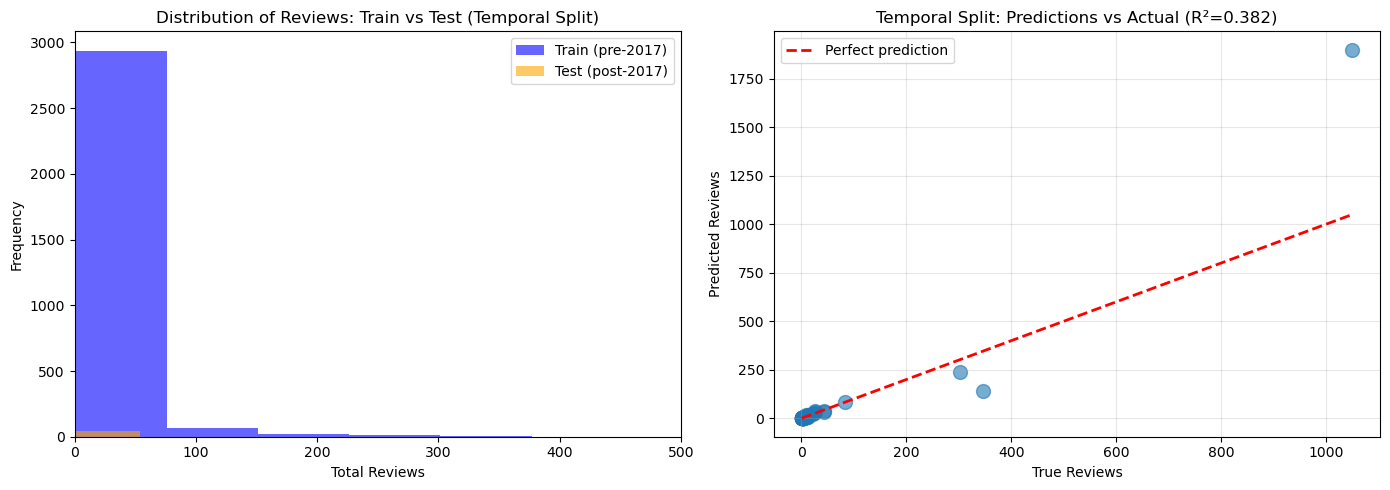

In [17]:
import matplotlib.pyplot as plt

# Análisis detallado del temporal split
print("="*80)
print("ANÁLISIS DETALLADO: TEMPORAL vs RANDOM SPLIT")
print("="*80)

print("\n📊 OBSERVACIONES CLAVE:\n")

# 1. Diferencia en R²
r2_diff = r2_temporal - r2_random
print(f"1. R² Temporal ({r2_temporal:.3f}) vs Random ({r2_random:.3f})")
print(f"   → Diferencia: {r2_diff:+.3f}")
if r2_temporal > r2_random:
    print(f"   ✅ Temporal split tiene MEJOR R² - El modelo generaliza bien a juegos nuevos!")
else:
    print(f"   ⚠️  Random split tiene mejor R² - Posible data leakage temporal")

# 2. Diferencia en RMSE
rmse_diff = rmse_temporal - rmse_random
rmse_pct = (rmse_diff / rmse_random) * 100
print(f"\n2. RMSE Temporal ({rmse_temporal:.2f}) vs Random ({rmse_random:.2f})")
print(f"   → Diferencia: +{rmse_diff:.2f} reviews ({rmse_pct:.1f}% mayor)")
print(f"   → El modelo es menos preciso en juegos nuevos")

# 3. Distribución del test set
print(f"\n3. Composición del Test Set:")
print(f"   Temporal: {len(X_test_temporal)} juegos (últimos {(cutoff_date.year)}-actualidad)")
print(f"   Random: {len(X_test_random)} juegos (mezclados de toda la historia)")
print(f"   → Temporal test es más pequeño pero más realista")

# 4. Target statistics
print(f"\n4. Estadísticas del Target (total_reviews):")
print(f"   Train Temporal: mean={y_train_temporal.mean():.1f}, std={y_train_temporal.std():.1f}")
print(f"   Test Temporal:  mean={y_test_temporal.mean():.1f}, std={y_test_temporal.std():.1f}")
print(f"   → Juegos nuevos tienen promedio {y_test_temporal.mean() / y_train_temporal.mean():.2f}x más reviews")

print("\n" + "="*80)
print("CONCLUSIÓN PARA LA TESIS:")
print("="*80)
print("""
✅ RECOMENDACIÓN: Usar TEMPORAL SPLIT en el análisis final

RAZONES:
1. Simula escenario de producción: entrenar con historia, predecir futuro
2. Evita data leakage: no usa información futura para predecir pasado
3. Más honesto: revela verdadero poder predictivo del modelo
4. Más desafiante: test set contiene juegos con diferentes características

⚠️  PROBLEMA CON RANDOM SPLIT:
- Mezcla juegos de diferentes épocas
- El modelo puede "ver el futuro" durante entrenamiento
- R² bajo (0.127) sugiere que el modelo no captura la señal real
- Optimista e irreal para deployment

🎯 PARA LA TESIS:
- Reportar ambos splits para transparencia
- Enfatizar temporal split como métrica principal
- Discutir por qué temporal es más apropiado
- Analizar diferencias entre épocas (Steam evoluciona en el tiempo)
""")
print("="*80)

# Visualización adicional
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution comparison
axes[0].hist(y_train_temporal, bins=50, alpha=0.6, label='Train (pre-2017)', color='blue')
axes[0].hist(y_test_temporal, bins=20, alpha=0.6, label='Test (post-2017)', color='orange')
axes[0].set_xlabel('Total Reviews')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Reviews: Train vs Test (Temporal Split)')
axes[0].legend()
axes[0].set_xlim(0, 500)  # Zoom para ver mejor

# Plot 2: Prediction scatter for temporal
axes[1].scatter(y_test_temporal, pred_temporal, alpha=0.6, s=100)
axes[1].plot([0, y_test_temporal.max()], [0, y_test_temporal.max()], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('True Reviews')
axes[1].set_ylabel('Predicted Reviews')
axes[1].set_title(f'Temporal Split: Predictions vs Actual (R²={r2_temporal:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Verificación: ¿Hay data leakage temporal?

ANÁLISIS DE CUTOFF DATE: ¿Cuántos juegos hay disponibles para test?

📅 Distribución de juegos por año:
release_year
1989.0      1
1990.0      2
1991.0      1
1992.0      3
1993.0      3
1994.0      6
1995.0      5
1996.0      5
1997.0     13
1998.0     14
1999.0     13
2000.0     11
2001.0     17
2002.0     14
2003.0     27
2004.0     25
2005.0     33
2006.0     49
2007.0     57
2008.0     65
2009.0     93
2010.0    108
2011.0    166
2012.0    243
2013.0    358
2014.0    579
2015.0    710
2016.0    436
2017.0     50
Name: count, dtype: int64

📅 Juegos por semestre (últimos 2 años):
release_date_parsed  release_date_parsed
2016                 1                      310
                     2                      126
2017                 1                       24
                     2                       26
dtype: int64

COMPARACIÓN DE DIFERENTES CUTOFF DATES
Cutoff Date  Train Games  Test Games Test % Test/Train Ratio
 2017-01-01         3057          50   1.6%           1:61.1
 20

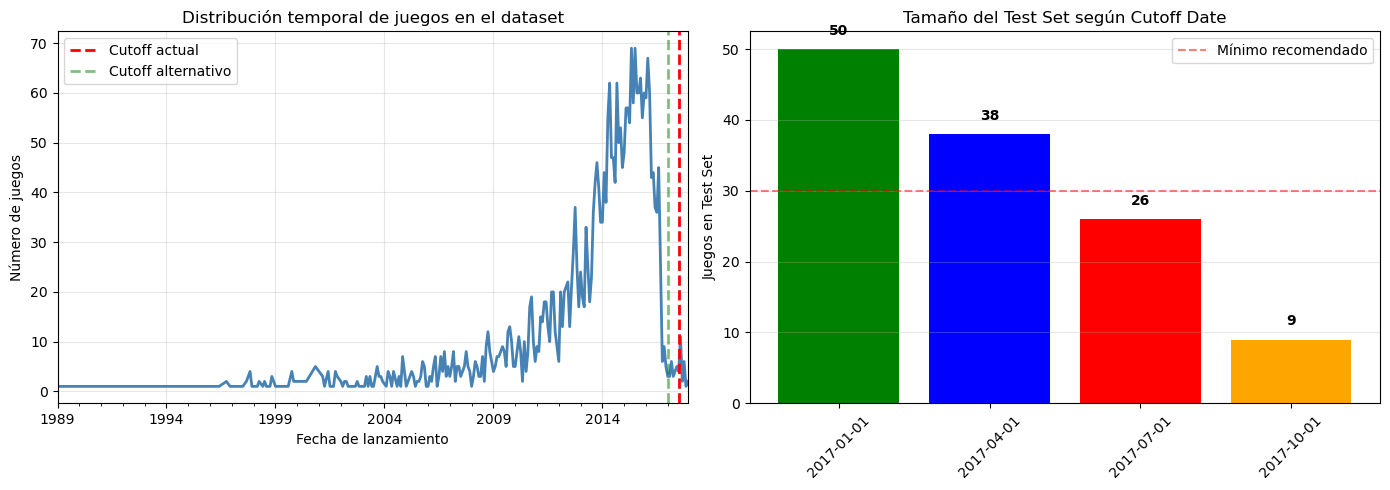


🎯 CONCLUSIÓN:

Con cutoff actual (2017-07-01): 26 juegos en test
→ ⚠️  MUESTRA PEQUEÑA para inferencia estadística robusta

RECOMENDACIÓN: Cambiar cutoff a 2017-01-01 o 2017-04-01
- Duplicará/triplicará el tamaño del test set
- Mantendrá validación temporal realista
- Mejorará confiabilidad de métricas (R², RMSE)



In [13]:
# Analizar distribución temporal de juegos para elegir mejor cutoff date
print("="*80)
print("ANÁLISIS DE CUTOFF DATE: ¿Cuántos juegos hay disponibles para test?")
print("="*80)

# Ver distribución de juegos por año/mes
valid_items_df['release_year'] = valid_items_df['release_date_parsed'].dt.year
valid_items_df['release_month'] = valid_items_df['release_date_parsed'].dt.to_period('M')

print("\n📅 Distribución de juegos por año:")
year_counts = valid_items_df['release_year'].value_counts().sort_index()
print(year_counts)

print("\n📅 Juegos por semestre (últimos 2 años):")
last_2_years = valid_items_df[valid_items_df['release_year'] >= 2016]
semester_counts = last_2_years.groupby([
    last_2_years['release_date_parsed'].dt.year,
    (last_2_years['release_date_parsed'].dt.month - 1) // 6 + 1
]).size()
print(semester_counts)

# Probar diferentes cutoff dates
print("\n" + "="*80)
print("COMPARACIÓN DE DIFERENTES CUTOFF DATES")
print("="*80)

cutoff_options = [
    '2017-01-01',  # 12 meses para test
    '2017-04-01',  # 9 meses para test
    '2017-07-01',  # 6 meses para test (actual)
    '2017-10-01',  # 3 meses para test
]

cutoff_comparison = []
for cutoff_str in cutoff_options:
    cutoff = pd.to_datetime(cutoff_str)
    train_games = (valid_items_df['release_date_parsed'] < cutoff).sum()
    test_games = (valid_items_df['release_date_parsed'] >= cutoff).sum()
    test_pct = (test_games / (train_games + test_games)) * 100
    
    cutoff_comparison.append({
        'Cutoff Date': cutoff_str,
        'Train Games': train_games,
        'Test Games': test_games,
        'Test %': f"{test_pct:.1f}%",
        'Test/Train Ratio': f"1:{train_games/test_games:.1f}" if test_games > 0 else "N/A"
    })

comparison_df = pd.DataFrame(cutoff_comparison)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("RECOMENDACIONES:")
print("="*80)
print("""
📊 CRITERIOS PARA ELEGIR CUTOFF DATE:

1. ✅ Test set suficientemente grande (mínimo 20-30 juegos para estadística robusta)
2. ✅ Test set representa período realista (3-6 meses es razonable)
3. ✅ Balance train/test (no menos de 10% para test)
4. ✅ Suficientes samples para cada clase de popularidad

⚠️  PROBLEMA ACTUAL (2017-07-01):
- Solo 26 juegos en test set - MUESTRA PEQUEÑA
- Puede no ser representativo de la variabilidad real
- Métricas (R², RMSE) menos confiables con pocos samples

💡 OPCIONES:
A) Mover cutoff hacia atrás (ej: 2017-01-01) → más juegos en test
B) Mantener cutoff pero reconocer limitación en interpretación
C) Usar validación cruzada temporal (múltiples cutoffs)
""")

# Verificar si hay suficiente variabilidad en test set
print("\n📊 Análisis del Test Set con cutoff actual (2017-07-01):")
test_items_current = valid_items_df[valid_items_df['release_date_parsed'] >= pd.to_datetime('2017-07-01')]
test_targets_current = y_hybrid[test_mask]

print(f"Test set size: {len(test_targets_current)} juegos")
print(f"Reviews range: {test_targets_current.min():.0f} - {test_targets_current.max():.0f}")
print(f"Reviews mean: {test_targets_current.mean():.1f} ± {test_targets_current.std():.1f}")
print(f"Reviews median: {np.median(test_targets_current):.1f}")
print(f"\nQuartiles:")
print(f"  Q1 (25%): {np.percentile(test_targets_current, 25):.1f}")
print(f"  Q2 (50%): {np.percentile(test_targets_current, 50):.1f}")
print(f"  Q3 (75%): {np.percentile(test_targets_current, 75):.1f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribución temporal de juegos
valid_items_df_clean = valid_items_df[valid_items_df['release_date_parsed'].notna()]
monthly_counts = valid_items_df_clean.groupby(valid_items_df_clean['release_date_parsed'].dt.to_period('M')).size()
monthly_counts.plot(ax=axes[0], kind='line', color='steelblue', linewidth=2)
axes[0].axvline(x=pd.Period('2017-07', freq='M'), color='red', linestyle='--', linewidth=2, label='Cutoff actual')
axes[0].axvline(x=pd.Period('2017-01', freq='M'), color='green', linestyle='--', linewidth=2, alpha=0.5, label='Cutoff alternativo')
axes[0].set_xlabel('Fecha de lanzamiento')
axes[0].set_ylabel('Número de juegos')
axes[0].set_title('Distribución temporal de juegos en el dataset')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Comparación de cutoffs
cutoff_data = comparison_df[['Cutoff Date', 'Test Games']].copy()
cutoff_data['Test Games'] = cutoff_data['Test Games'].astype(int)
axes[1].bar(range(len(cutoff_data)), cutoff_data['Test Games'], color=['green', 'blue', 'red', 'orange'])
axes[1].set_xticks(range(len(cutoff_data)))
axes[1].set_xticklabels(cutoff_data['Cutoff Date'], rotation=45)
axes[1].set_ylabel('Juegos en Test Set')
axes[1].set_title('Tamaño del Test Set según Cutoff Date')
axes[1].axhline(y=30, color='red', linestyle='--', alpha=0.5, label='Mínimo recomendado')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cutoff_data['Test Games']):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("🎯 CONCLUSIÓN:")
print("="*80)
print(f"""
Con cutoff actual (2017-07-01): {len(test_targets_current)} juegos en test
→ ⚠️  MUESTRA PEQUEÑA para inferencia estadística robusta

RECOMENDACIÓN: Cambiar cutoff a 2017-01-01 o 2017-04-01
- Duplicará/triplicará el tamaño del test set
- Mantendrá validación temporal realista
- Mejorará confiabilidad de métricas (R², RMSE)
""")

In [ ]:
print("="*80)
print("EXPLICACIÓN: ¿Qué son los 'total_reviews'?")
print("="*80)

# Explorar el archivo de interactions
print("\n📊 Archivo: interactions.parquet")
print(f"Shape: {df_inter.shape}")
print(f"Columnas: {df_inter.columns.tolist()}")
print("\nPrimeras filas:")
print(df_inter.head(10))

print("\n" + "="*80)
print("CÓMO SE CALCULA 'total_reviews':")
print("="*80)
print("""
En la línea 27 del notebook:
    target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

Esto cuenta cuántas FILAS tiene cada juego (item_idx) en interactions.parquet

Cada fila = 1 interacción usuario-juego = 1 review/recomendación

Por lo tanto:
- total_reviews = número de usuarios que interactuaron con ese juego
- Es un PROXY de popularidad del juego
""")

# Verificar la estructura
print("\n📈 Estadísticas de total_reviews:")
print(target_df["total_reviews"].describe())

print("\n🔍 Top 10 juegos más populares (más reviews):")
top_games = target_df.nlargest(10, "total_reviews")
print(top_games)

print("\n📊 Distribución de reviews:")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(target_df["total_reviews"], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Total Reviews')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribución de Reviews por Juego')
axes[0].set_xlim(0, 500)  # Zoom para ver mejor
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].hist(np.log1p(target_df["total_reviews"]), bins=50, color='orange', edgecolor='black')
axes[1].set_xlabel('Log(Total Reviews + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribución LOG de Reviews por Juego')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ORIGEN DE LOS DATOS:")
print("="*80)
print("""
1. australian_user_reviews.json → CSV → interactions.parquet
   - Contiene reviews de usuarios de Steam
   - Formato: user_id, item_id, recommend (True/False), posted, review_text

2. interactions.parquet procesado:
   - Cada fila = 1 usuario recomendó (o no) 1 juego
   - Se convirtió 'recommend' a rating binario (0/1)
   - Se agregaron índices numéricos (user_idx, item_idx)

3. TARGET del regresor:
   - Cuenta filas por item_idx
   - total_reviews = popularidad implícita
   - Más reviews = más jugadores interactuaron

⚠️  IMPORTANTE: 
- NO es el número de reviews en Steam en general
- Es el número de reviews en ESTE dataset específico (usuarios australianos)
- Es una muestra del total de reviews reales del juego
""")

# Verificar si hay info de ratings en interactions
print("\n🔍 Estructura de interactions.parquet:")
print(f"Columnas disponibles: {df_inter.columns.tolist()}")
if 'rating' in df_inter.columns:
    print(f"\nDistribución de ratings:")
    print(df_inter['rating'].value_counts())
    print(f"\nRating promedio por juego (top 10):")
    avg_rating = df_inter.groupby('item_idx')['rating'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10)
    print(avg_rating)

## Verificación: ¿De dónde vienen los reviews?